In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import matplotlib.ticker as ticker

import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 40

In [4]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


<class 'dict'>


In [7]:
pos = halos["GroupPos"]/1e3

In [8]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [9]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [10]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [11]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [12]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [ ]:
sum_sfrs = np.zeros(len(halos["GroupFirstSub"]))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/tmp/ipykernel_250324/2917215634.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sfrs = np.log10(sum_sfrs)


In [14]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [15]:

sum_sat_mass = np.zeros(len(halos["GroupFirstSub"]))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/tmp/ipykernel_250324/1382896502.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sat_mass = np.log10(sum_sat_mass)


In [16]:
mvir = np.log10(halos["Group_M_TopHat200"])+10

/tmp/ipykernel_250324/2317019756.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"])+10


In [17]:
group_sfrs = np.log10(halos["GroupSFR"])

/tmp/ipykernel_250324/618587702.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(halos["GroupSFR"])


[10.07733468 11.24614748 11.45967398 11.72655392 12.67361096]


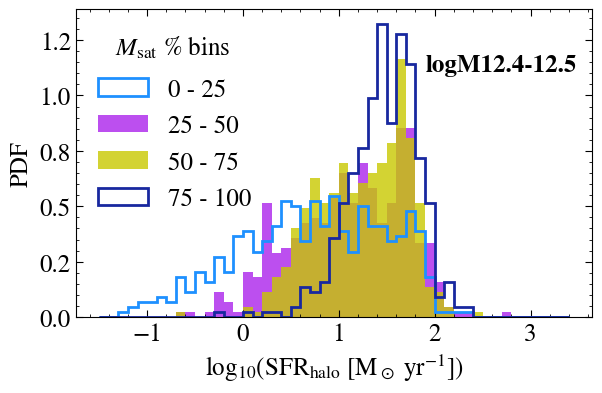

In [24]:
bins=np.arange(-1.5, 3.5, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
#color_list = palette_tab10[5:]
color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
#color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
color_list = ["dodgerblue", "#AC23EB", "#c8c800","#18289F"]
#color_list = ["green","#AC23EB","#c8c800","#18289F"]
logM = 12.4
mask2 = (mvir> logM) & (mvir < logM+0.1) 
median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    if (i == 1) or (i == 2):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.8, color=color_list[i])# facecolor="none", edgecolor=color_list[i])
    elif (i == 0) or (i == 3):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step', linewidth=2)# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm halo}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.97,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"$M_{\rm sat}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.savefig("../figures/hist_logM12.4-12.5_msat.pdf", format="pdf", bbox_inches="tight")

In [19]:
logMs = np.arange(11,14, 0.1)
nbins = len(logMs)

compute_iqr = True

new_medians_arr = np.zeros((4,nbins), dtype=float)

if compute_iqr:
    new_iqrs_arr = np.zeros((4,nbins), dtype=float)
    orig_iqrs = []

for ibin, logM in enumerate(logMs):
    mask2 = (mvir> logM) & (mvir < logM+0.1)
    
    percentile_list = [0, 25, 50, 75, 100]
    percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)
    
    if compute_iqr:
        if np.sum(mask2) > 4:
            ps = np.nanpercentile(group_sfrs[mask2], q=[25,75])
            iqr = ps[1] - ps[0]
            orig_iqrs.append(iqr)


    new_medians = []
    

    for ip, percentile in enumerate(percentiles[:4]):
        mask = (sum_sat_mass[mask2] > percentiles[ip]) & (sum_sat_mass[mask2] < percentiles[ip+1]) #& (group_sfrs[mask2] > -5)
        masks.append(mask)
        #plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
        if compute_iqr:
            if len(group_sfrs[mask2][mask]) > 4:
                ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
                iqr = ps[1] - ps[0]
                new_iqrs_arr[ip][ibin] = iqr
            else:
                new_iqrs_arr[ip][ibin] = np.nan
        
        #print(np.nanstd(group_sfrs[mask2][mask]))
        med = np.nanmedian(group_sfrs[mask2][mask])
        new_medians.append(med)
        new_medians_arr[ip][ibin] = med
        

/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4657: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))


In [20]:
logMs = np.arange(11,14, 0.1)
nbins = len(logMs)

compute_iqr = True

new_medians_arr = np.zeros((4,nbins), dtype=float)

nhalos = []

if compute_iqr:
    new_iqrs_arr = np.zeros((4,nbins), dtype=float)
    orig_iqrs = []
sum_sat_mass_inf_replaced = np.where(sum_sat_mass < 0, -5, sum_sat_mass)
for ibin, logM in enumerate(logMs):
    mask2 = (mvir> logM) & (mvir < logM+0.1)
    
    nhalos.append(np.sum(mask2))
    percentile_list = [0, 25, 50, 75, 100]
    percentiles = np.nanpercentile(sum_sat_mass_inf_replaced[mask2], percentile_list)
    #print(sum_sat_mass[mask2])
    #print(percentiles)
    if compute_iqr:
        if np.sum(mask2) > 4:
            ps = np.nanpercentile(group_sfrs[mask2], q=[25,75])
            iqr = ps[1] - ps[0]
            orig_iqrs.append(iqr)


    
    

    for ip, percentile in enumerate(percentiles[:4]):
        mask = (sum_sat_mass_inf_replaced[mask2] > percentiles[ip]) & (sum_sat_mass_inf_replaced[mask2] < percentiles[ip+1]) #& (group_sfrs[mask2] > -5)
        masks.append(mask)
        #plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
        if compute_iqr:
            if len(group_sfrs[mask2][mask]) > 4:
                ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
                iqr = ps[1] - ps[0]
                new_iqrs_arr[ip][ibin] = iqr
            else:
                new_iqrs_arr[ip][ibin] = np.nan
        
        #print(np.nanstd(group_sfrs[mask2][mask]))
        med = np.nanmedian(group_sfrs[mask2][mask])
        new_medians.append(med)
        new_medians_arr[ip][ibin] = med
        

In [21]:
print(sum_sat_mass)
print(sum_sat_mass_inf_replaced)

[13.6936057  13.13904087 13.36115507 ...        -inf        -inf
        -inf]
[13.6936057  13.13904087 13.36115507 ... -5.         -5.
 -5.        ]


In [22]:
print(nhalos.index(101))
print(nhalos)

23
[44545, 36444, 29524, 24562, 20239, 16372, 13148, 10657, 8309, 6805, 5381, 4187, 3167, 2558, 1789, 1307, 992, 720, 514, 364, 268, 173, 127, 101, 63, 45, 19, 12, 14, 6]


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250324/3341389073.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


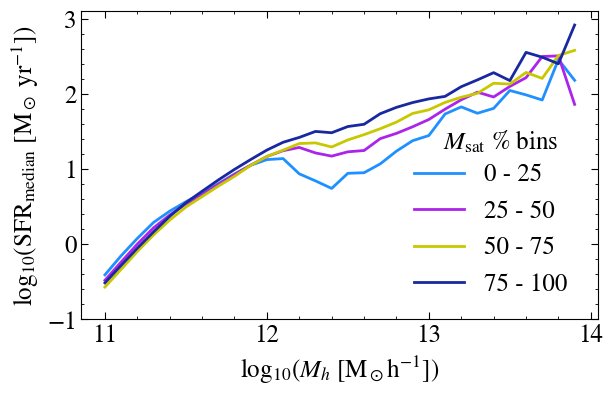

In [25]:
for ip in range(4):
    plt.plot(logMs, new_medians_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    

    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$M_{\rm sat}$ % bins", (0.7,0.55), xycoords="axes fraction", ha="left")
#plt.annotate("Median of each"+ "\n" + r"$M_{\rm sat}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_h$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)

#plt.savefig("../figures/median_msat.pdf", format="pdf", bbox_inches="tight")

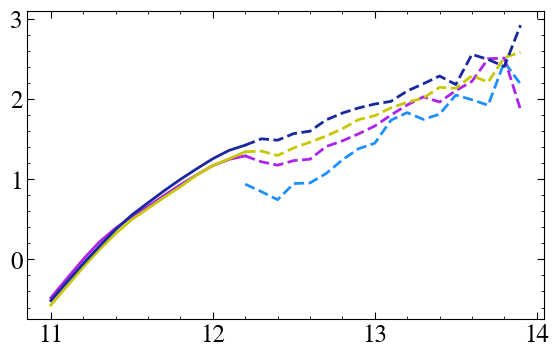

In [23]:
index = 13
for ip in range(4):
    plt.plot(logMs[:index], new_medians_arr[ip][:index],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    plt.plot(logMs[index-1:], new_medians_arr[ip][index-1:], color=color_list[ip], linestyle="dashed")

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250324/1975005751.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


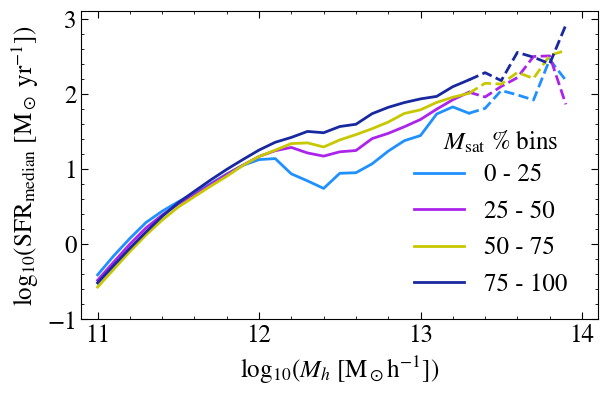

In [26]:
index = 23
for ip in range(4):
    plt.plot(logMs[:index+1], new_medians_arr[ip][:index+1],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    plt.plot(logMs[index:], new_medians_arr[ip][index:], color=color_list[ip], linestyle="dashed")

    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$M_{\rm sat}$ % bins", (0.7,0.55), xycoords="axes fraction", ha="left")
#plt.annotate("Median of each"+ "\n" + r"$M_{\rm sat}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{h}$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)
plt.xlim(10.9,14.1)
plt.savefig("../figures/median_msat_w_dashed.pdf", format="pdf", bbox_inches="tight")

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_250324/3957027539.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('IQR of log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


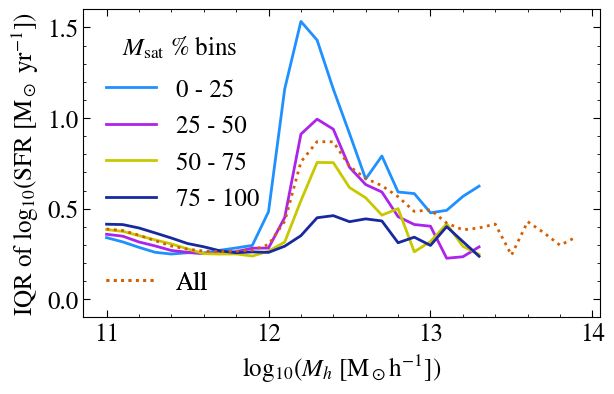

In [27]:

for ip in range(4):
    plt.plot(logMs[:index+1], new_iqrs_arr[ip][:index+1],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    
plt.plot(logMs, orig_iqrs, color=palette_tab10[3], linestyle="dotted", label="All")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles=handles[:-1],loc="upper left", bbox_to_anchor=(0,0.85))
ax.add_artist(leg)
leg = ax.legend(handles=handles[-1:], loc="lower left")
ax.add_artist(leg)  

    
#plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.annotate(r"$M_{\rm sat}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")
#plt.annotate("IQR for each"+ "\n" + r"$M_{\rm sat}$ bin", (0.7,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{h}$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('IQR of log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-0.1,1.6)

plt.savefig("../figures/iqr_msat.pdf", format="pdf", bbox_inches="tight")